# MLP from Scratch on UCI Wine Dataset

This notebook demonstrates a fully connected Multi-Layer Perceptron (MLP) implemented from scratch using NumPy.

We evaluate it on the UCI Wine dataset.

We will cover:
- Dataset loading and preprocessing  
- Model architecture  
- Training with backpropagation  
- Evaluation  
- Loss visualization  

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from rice_ml import train_test_split, StandardScaler, accuracy_score, confusion_matrix

# Load UCI Wine Dataset

The Wine dataset contains:
- 13 numerical features
- 3 wine classes
- 178 total samples

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

print("Feature shape:", X.shape)
print("Classes:", np.unique(y))
print("Class names:", wine.target_names)

Feature shape: (178, 13)
Classes: [0 1 2]
Class names: ['class_0' 'class_1' 'class_2']


# Understanding the Dataset

Before training, it helps to understand the distribution of features in the Wine dataset.

We visualize histograms of a few key features to see how separable the classes might be.

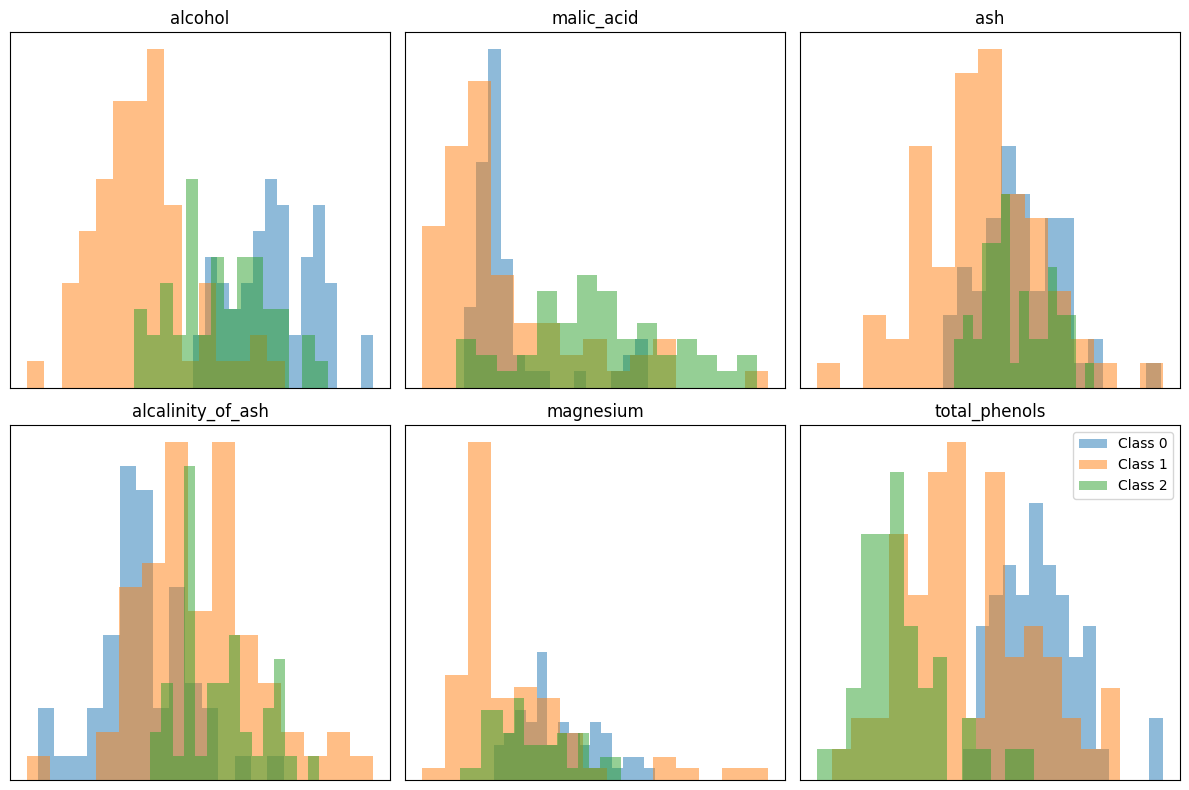

In [10]:
feature_names = wine.feature_names

plt.figure(figsize=(12, 8))

for i in range(6):  # first 6 features for readability
    plt.subplot(2, 3, i + 1)
    
    for c in np.unique(y):
        plt.hist(X[y == c, i], bins=15, alpha=0.5, label=f"Class {c}")
    
    plt.title(feature_names[i])
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.legend()
plt.show()

# Train-Test Split + Standardization

We split the dataset and standardize features for stable gradient descent.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Setup

We define a network to better utilize the richer feature space:

- Input: 13 features  
- Hidden layers: 32 → 16  
- Output: 3 classes  
- Activation: tanh  

In [4]:
from rice_ml import MLP

mlp = MLP(
    shape=[13, 32, 16, 3],
    activation="tanh",
    lr=0.03,
    reg=1e-3,
    seed=42
)

# Training Loop

We train using full-batch gradient descent:
- Forward pass
- Backpropagation
- Parameter updates
- Track loss

In [5]:
loss_history = mlp.train(
    X_train,
    y_train,
    steps=10000,
    verbose=True,
    track_loss=True
)

step 0, loss = 1.3845
step 1000, loss = 0.1611
step 2000, loss = 0.1221
step 3000, loss = 0.1017
step 4000, loss = 0.0887
step 5000, loss = 0.0798
step 6000, loss = 0.0734
step 7000, loss = 0.0689
step 8000, loss = 0.0656
step 9000, loss = 0.0632


# Training Loss Curve

We visualize convergence of gradient descent.

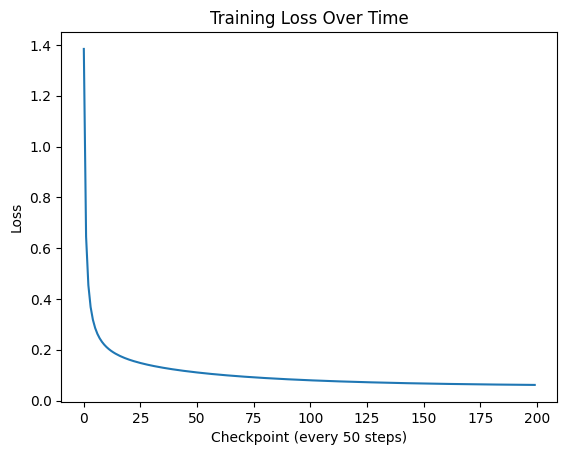

In [6]:
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Checkpoint (every 50 steps)")
plt.ylabel("Loss")
plt.show()

# Model Evaluation

We evaluate performance using accuracy on train and test sets.

In [8]:
train_preds = mlp.predict(X_train)
test_preds = mlp.predict(X_test)

train_acc = accuracy_score(y_train, train_preds) * 100
test_acc = accuracy_score(y_test, test_preds) * 100

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy:  {test_acc:.2f}%")

Train Accuracy: 100.00%
Test Accuracy:  91.89%


# Confusion Matrix

A confusion matrix shows where the model is making mistakes across classes.

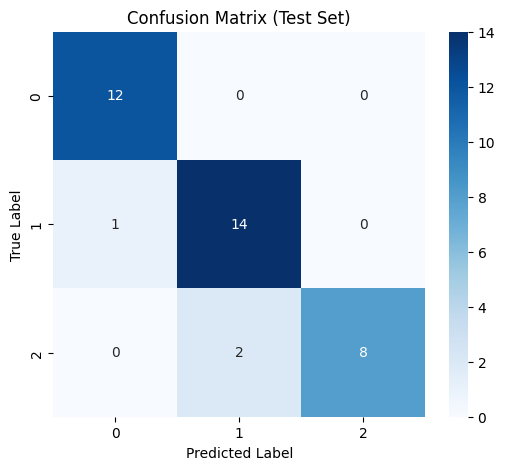

In [14]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Conclusion

This notebook demonstrates a neural network implemented entirely from scratch.

Key takeaways:
- Multi-class classification beyond Iris complexity  
- Manual backpropagation implementation  
- Strong performance on real UCI tabular data  
- Fully NumPy-based training pipeline  

This model can be extended to:
- mini-batch SGD  
- dropout  
- deeper architectures  
- different UCI datasets  